# NFL Defensive Combine Analytics

**Research question:** How well do combine measurables and draft capital predict NFL career success for defensive prospects?

**Data:** NFL Combine, 2000–2018 · Analysis uses defensive positions with PFR-linked career AV where noted.

## Phase 1: Clean defensive dataset

**Goal:** Filter to defensive positions and add `was_drafted` and `has_pfr_id` flags.

**Output:** `df_def` (2,780 rows), `df_analysis` (2,298 PFR-linked rows for AV analysis), `defensive_combine_clean.csv`

In [92]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.expand_frame_repr", False)

_csv_name = "combine_data_since_2000_PROCESSED_2018-04-26.csv"
_here = Path.cwd().resolve()
_csv = next(
    (base / ":data" / _csv_name for base in (_here, *_here.parents) if (base / ":data" / _csv_name).is_file()),
    None,
)
if _csv is None:
    raise FileNotFoundError(f"Could not locate :data/{_csv_name} (cwd={_here})")

df = pd.read_csv(_csv)

print("shape (rows, cols):", df.shape)
print("columns:", list(df.columns))
df.head(15)

df.info()
df.describe()

shape (rows, cols): (6218, 16)
columns: ['Player', 'Pos', 'Ht', 'Wt', 'Forty', 'Vertical', 'BenchReps', 'BroadJump', 'Cone', 'Shuttle', 'Year', 'Pfr_ID', 'AV', 'Team', 'Round', 'Pick']
<class 'pandas.DataFrame'>
RangeIndex: 6218 entries, 0 to 6217
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Player     6218 non-null   str    
 1   Pos        6218 non-null   str    
 2   Ht         6218 non-null   int64  
 3   Wt         6218 non-null   int64  
 4   Forty      6046 non-null   float64
 5   Vertical   4796 non-null   float64
 6   BenchReps  4212 non-null   float64
 7   BroadJump  4754 non-null   float64
 8   Cone       3993 non-null   float64
 9   Shuttle    4063 non-null   float64
 10  Year       6218 non-null   int64  
 11  Pfr_ID     4895 non-null   str    
 12  AV         6218 non-null   float64
 13  Team       3738 non-null   str    
 14  Round      3738 non-null   float64
 15  Pick       3738 non-null   float64

,Ht,Wt,Forty,Vertical,BenchReps,BroadJump,Cone,Shuttle,Year,AV,Round,Pick
count,6218.000000,6218.000000,6046.000000,4796.000000,4212.000000,4754.000000,3993.000000,4063.000000,6218.000000,6218.000000,3738.000000,3738.000000
mean,73.798971,243.372145,4.783784,32.818599,20.926163,113.943837,7.282307,4.390603,2009.041975,5.085719,3.838684,113.728464
std,2.621373,45.103814,0.305984,4.213729,6.393679,9.317031,0.422882,0.268836,5.471056,7.546556,1.952728,70.605155
min,65.000000,149.000000,4.220000,17.500000,2.000000,74.000000,6.280000,3.730000,2000.000000,-4.000000,1.000000,1.000000
25%,72.000000,206.000000,4.540000,30.000000,16.000000,108.000000,6.970000,4.190000,2004.000000,0.000000,2.000000,53.000000
50%,74.000000,233.000000,4.700000,33.000000,21.000000,115.000000,7.190000,4.350000,2009.000000,1.000000,4.000000,108.000000
75%,76.000000,281.000000,4.980000,35.500000,25.000000,121.000000,7.540000,4.560000,2014.000000,8.000000,5.000000,169.000000
max,82.000000,375.000000,6.050000,46.000000,49.000000,147.000000,9.120000,5.560000,2018.000000,51.000000,7.000000,260.000000


In [93]:
DEF_POS = ["DE", "DT", "NT", "EDGE", "OLB", "ILB", "LB", "CB", "DB", "S", "FS", "SS"]

df_def = df[df["Pos"].isin(DEF_POS)].copy()
print("defensive rows:", len(df_def))
df_def["Pos"].value_counts()

defensive rows: 2780


Pos
CB      630
DE      487
DT      463
OLB     424
ILB     276
FS      229
SS      213
S        27
EDGE     23
NT        3
LB        3
DB        2
Name: count, dtype: int64

In [94]:
df_def["was_drafted"] = df_def["Round"].notna()
df_def["has_pfr_id"] = df_def["Pfr_ID"].notna()

print(df_def[["was_drafted", "has_pfr_id"]].mean().round(3))

was_drafted    0.657
has_pfr_id     0.827
dtype: float64


In [95]:
df_analysis = df_def[df_def["has_pfr_id"]].copy()
print("rows for AV analysis:", len(df_analysis))

rows for AV analysis: 2298


In [96]:
miss_pct = (df_def.isna().mean() * 100).sort_values(ascending=False)
miss_pct[miss_pct > 0].round(1)

Cone         35.5
Pick         34.3
Round        34.3
Team         34.3
Shuttle      34.2
BenchReps    21.7
BroadJump    21.0
Vertical     20.9
Pfr_ID       17.3
Forty         2.2
dtype: float64

In [97]:
df_def.head()
df_def.info()

<class 'pandas.DataFrame'>
Index: 2780 entries, 0 to 6217
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player       2780 non-null   str    
 1   Pos          2780 non-null   str    
 2   Ht           2780 non-null   int64  
 3   Wt           2780 non-null   int64  
 4   Forty        2719 non-null   float64
 5   Vertical     2198 non-null   float64
 6   BenchReps    2176 non-null   float64
 7   BroadJump    2197 non-null   float64
 8   Cone         1793 non-null   float64
 9   Shuttle      1830 non-null   float64
 10  Year         2780 non-null   int64  
 11  Pfr_ID       2298 non-null   str    
 12  AV           2780 non-null   float64
 13  Team         1827 non-null   str    
 14  Round        1827 non-null   float64
 15  Pick         1827 non-null   float64
 16  was_drafted  2780 non-null   bool   
 17  has_pfr_id   2780 non-null   bool   
dtypes: bool(2), float64(9), int64(3), str(4)
memory usage: 374.6 KB


In [98]:
out = _csv.parent / "defensive_combine_clean.csv"
df_def.to_csv(out, index=False)
print("Saved to", out)

Saved to /Users/jorgegonzalez/Desktop/nfl-defensive-analytics/:data/defensive_combine_clean.csv


## Phase 2: Career AV by draft round

**Cohort:** Defensive players with PFR id (`df_analysis`), drafted only for the chart.

**Metric:** Mean career Approximate Value (AV) by draft round.

In [99]:
import matplotlib.pyplot as plt

drafted = df_analysis[df_analysis["was_drafted"]].copy()

by_round = (
    drafted.groupby("Round", as_index=False)["AV"]
    .agg(mean_av="mean", player_count="count")
    .sort_values("Round")
)

by_round

,Round,mean_av,player_count
0,1.0,16.270548,292
1,2.0,10.744898,294
2,3.0,7.046980,298
3,4.0,6.415162,277
4,5.0,4.868852,244
5,6.0,3.762626,198
6,7.0,3.502646,189


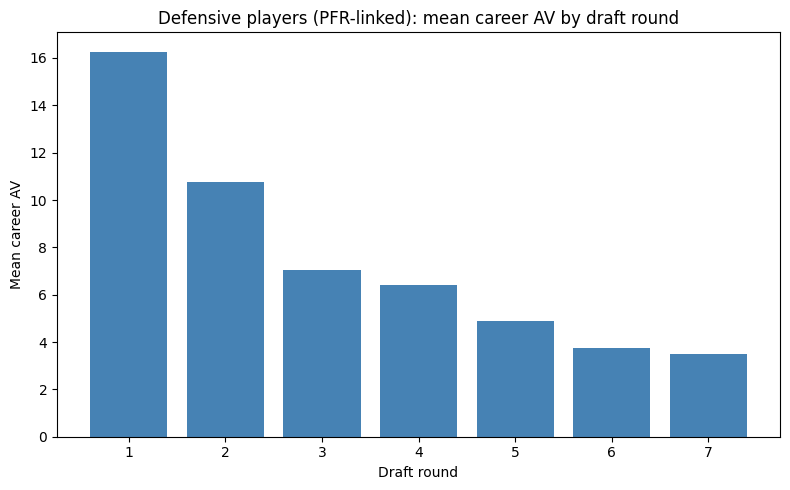

In [100]:
plt.figure(figsize=(8, 5))
plt.bar(by_round["Round"].astype(int), by_round["mean_av"], color="steelblue")
plt.xlabel("Draft round")
plt.ylabel("Mean career AV")
plt.title("Defensive players (PFR-linked): mean career AV by draft round")
plt.xticks(by_round["Round"].astype(int))
plt.tight_layout()
plt.show()

**Takeaway:** Round 1 defenders average about **16.3** career AV; Round 7 averages about **3.5**. Undrafted players in this cohort average about **1.6**. Draft round is strongly associated with career AV in this dataset.

### Additional context: Undrafted players

Players in `df_analysis` without draft round data. Not included in the round-by-round chart above.

In [101]:
undrafted = df_analysis[~df_analysis["was_drafted"]]
print("Undrafted count:", len(undrafted))
print("Undrafted mean AV:", undrafted["AV"].mean().round(2))

Undrafted count: 506
Undrafted mean AV: 1.63


## Phase 3: 40-yard dash vs career AV (cornerbacks)

**Cohort:** PFR-linked CBs with a recorded 40-yard time.  
**Note:** Lower 40 time = faster. We expect faster CBs (lower times) to tend toward higher career AV, but the relationship is usually weaker than draft round.

In [102]:
cb = df_analysis[(df_analysis["Pos"] == "CB") & df_analysis["Forty"].notna()].copy()
print("CB with 40 time:", len(cb))
print("Forty range:", cb["Forty"].min(), "–", cb["Forty"].max())
print("Mean AV:", cb["AV"].mean().round(2))

## Peeking at the Data
cb.head(10)

CB with 40 time: 517
Forty range: 4.27 – 4.75
Mean AV: 5.86


,Player,Pos,Ht,Wt,Forty,Vertical,BenchReps,BroadJump,Cone,Shuttle,Year,Pfr_ID,AV,Team,Round,Pick,was_drafted,has_pfr_id
4,Rashard Anderson,CB,74,206,4.55,34.0,NaN,123.0,7.18,4.15,2000,AndeRa21,6.0,Carolina Panthers,1.0,23.0,True,True
9,Reggie Austin,CB,69,175,4.44,35.0,17.0,119.0,7.03,4.14,2000,AustRe20,3.0,Chicago Bears,4.0,125.0,True,True
13,David Barrett,CB,70,199,4.44,37.5,16.0,116.0,6.81,4.04,2000,BarrDa22,10.0,Arizona Cardinals,4.0,102.0,True,True
14,William Bartee,CB,73,192,4.43,38.5,NaN,124.0,6.70,3.99,2000,BartWi20,9.0,Kansas City Chiefs,2.0,54.0,True,True
17,Robert Bean,CB,71,178,4.50,34.5,NaN,122.0,6.87,4.20,2000,BeanRo20,5.0,Cincinnati Bengals,5.0,133.0,True,True
30,Ralph Brown,CB,70,185,4.55,NaN,10.0,NaN,NaN,NaN,2000,BrowRa20,4.0,New York Giants,5.0,140.0,True,True
49,Ike Charlton,CB,71,205,4.47,NaN,16.0,126.0,NaN,NaN,2000,CharIk20,4.0,Seattle Seahawks,2.0,52.0,True,True
67,Renard Cox,CB,71,192,4.68,38.0,13.0,111.0,7.10,NaN,2000,CoxxRe20,0.0,NaN,NaN,NaN,False,True
83,Mario Edwards,CB,72,191,4.46,NaN,NaN,120.0,NaN,NaN,2000,EdwaMa20,15.0,Dallas Cowboys,6.0,180.0,True,True
109,Dwayne Goodrich,CB,71,195,4.45,NaN,NaN,NaN,NaN,NaN,2000,GoodDw20,1.0,Dallas Cowboys,2.0,49.0,True,True


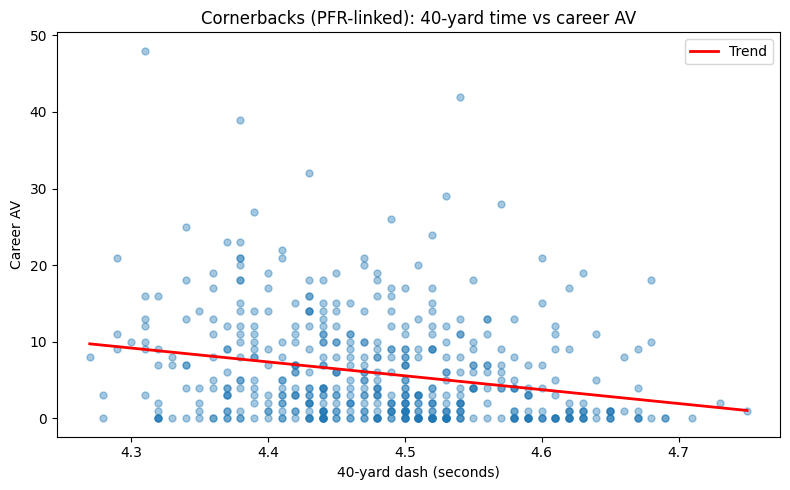

In [103]:
import numpy as np 

plt.figure(figsize=(8, 5))
plt.scatter(cb["Forty"], cb["AV"], alpha=0.4, s=25)
plt.xlabel("40-yard dash (seconds)")
plt.ylabel("Career AV")
plt.title("Cornerbacks (PFR-linked): 40-yard time vs career AV")
plt.tight_layout()

z = np.polyfit(cb["Forty"], cb["AV"], 1)
x_line = np.linspace(cb["Forty"].min(), cb["Forty"].max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), color="red", linewidth=2, label="Trend")
plt.legend()

plt.show()

In [104]:
corr = cb["Forty"].corr(cb["AV"])
print("Correlation (Forty vs AV):", round(corr, 3)) 

Correlation (Forty vs AV): -0.242


**Takeaway:** Among 517 PFR-linked cornerbacks with a 40 time, correlation between forty and career AV is **-0.24** (faster ↔ higher AV, weakly). Combine speed matters for CBs, but draft round (Phase 2) separates career outcomes more strongly in this dataset.

## Phase 4: 40-yard dash vs career AV by defensive group

**Goal:** Compare whether speed relates to career AV differently for defensive backs, linebackers, and defensive line / edge players.

**Note:** Lower 40-yard dash time means faster.

In [105]:
def assign_position_group(pos):
    if pos in ["CB", "DB", "S", "FS", "SS"]:
        return "DB"
    if pos in ["LB", "ILB", "OLB"]:
        return "LB"
    if pos in ["DE", "DT", "NT", "EDGE"]:
        return "DL/EDGE"
    return "Other"

df_analysis["position_group"] = df_analysis["Pos"].apply(assign_position_group)

df_analysis["position_group"].value_counts()

position_group
DB         897
DL/EDGE    799
LB         602
Name: count, dtype: int64

In [106]:
forty_group = (
    df_analysis[df_analysis["Forty"].notna()]
    .groupby("position_group")
    .apply(lambda g: pd.Series({
        "players": len(g),
        "mean_forty": round(g["Forty"].mean(), 2),
        "mean_av": round(g["AV"].mean(), 2),
        "forty_av_corr": round(g["Forty"].corr(g["AV"]), 3)
    }))
    .reset_index()
)

forty_group

,position_group,players,mean_forty,mean_av,forty_av_corr
0,DB,880.0,4.51,5.99,-0.186
1,DL/EDGE,785.0,4.95,6.92,-0.104
2,LB,589.0,4.70,7.48,-0.274


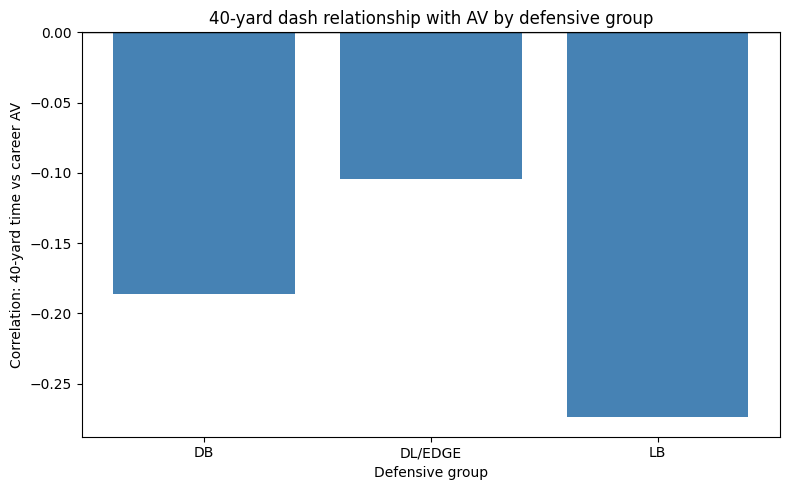

In [107]:
plt.figure(figsize=(8, 5))
plt.bar(forty_group["position_group"], forty_group["forty_av_corr"], color="steelblue")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Defensive group")
plt.ylabel("Correlation: 40-yard time vs career AV")
plt.title("40-yard dash relationship with AV by defensive group")

plt.tight_layout()

plt.show()

**Takeaway:** Across defensive groups, 40-yard dash time has a negative relationship with career AV, meaning faster players tend to have higher AV. The relationship is strongest for linebackers (`r = -0.274`), weaker for defensive backs (`r = -0.186`), and weakest for defensive line / edge players (`r = -0.104`). This suggests speed matters, but its importance depends on position group.